# Local Outlier Factor (LOF) for DDoS Detection - Complete Data

### Methodology:
1. **No Data Splitting:** The model is trained on 100% of the `BENIGN` traffic.
2. **Complete Evaluation:** The model predicts on the entire dataset (100% of BENIGN and 100% of DDoS).
3. **Security Metrics:** Evaluated using False Positive Rate (FPR), Benign Accuracy, and DDoS Detection Rate to prioritize low false alarms.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score
)


In [2]:
# Load the dataset
df = pd.read_csv("../data/ddos_clean.csv")

# Create binary anomaly label (1 for DDoS, 0 for BENIGN)
df["Anomaly"] = (df[" Label"] != "BENIGN").astype(int)

# Separate features and target
X = df.drop([" Label", "Anomaly"], axis=1)
y_true = df["Anomaly"]

print("Dataset shape:", df.shape)
print(y_true.value_counts())


Dataset shape: (225711, 44)
Anomaly
1    128025
0     97686
Name: count, dtype: int64


In [3]:
# Scale all data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Filter 100% of BENIGN traffic for training
X_train = X_scaled[y_true == 0]

print("Training samples (100% BENIGN):", X_train.shape)
print("Testing samples (Entire Dataset):", X_scaled.shape)


Training samples (100% BENIGN): (97686, 42)
Testing samples (Entire Dataset): (225711, 42)


In [4]:
def evaluate_lof(n_neighbors, contamination, X_train, X_test, y_true):
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        novelty=True,
        contamination=contamination
    )
    model.fit(X_train)

    y_pred = (model.predict(X_test) == -1).astype(int)

    # Extract confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate security-focused metrics
    fpr = fp / (fp + tn)                  # False Positive Rate (Alarm Fatigue)
    benign_acc = tn / (tn + fp)           # Specificity
    ddos_detection_rate = tp / (tp + fn)  # Sensitivity / Recall for DDoS
    f1 = f1_score(y_true, y_pred)

    return {
        "n_neighbors": n_neighbors,
        "contamination": contamination,
        "FPR": fpr,
        "Benign_Acc": benign_acc,
        "DDoS_Detection_Rate": ddos_detection_rate,
        "F1_Score": f1
    }


In [5]:
# Tune with realistic, low contamination rates
neighbors_list = [20, 50, 100]
contamination_list = [ 0.005, 0.01, 0.05,0.1,0.2,0.3]

results = []

for n in neighbors_list:
    for c in contamination_list:
        print(f"Testing n_neighbors={n}, contamination={c}...")
        res = evaluate_lof(n, c, X_train, X_scaled, y_true)
        results.append(res)


Testing n_neighbors=20, contamination=0.005...
Testing n_neighbors=20, contamination=0.01...
Testing n_neighbors=20, contamination=0.05...
Testing n_neighbors=20, contamination=0.1...
Testing n_neighbors=20, contamination=0.2...
Testing n_neighbors=20, contamination=0.3...
Testing n_neighbors=50, contamination=0.005...
Testing n_neighbors=50, contamination=0.01...
Testing n_neighbors=50, contamination=0.05...
Testing n_neighbors=50, contamination=0.1...
Testing n_neighbors=50, contamination=0.2...
Testing n_neighbors=50, contamination=0.3...
Testing n_neighbors=100, contamination=0.005...
Testing n_neighbors=100, contamination=0.01...
Testing n_neighbors=100, contamination=0.05...
Testing n_neighbors=100, contamination=0.1...
Testing n_neighbors=100, contamination=0.2...
Testing n_neighbors=100, contamination=0.3...


In [6]:
summary = pd.DataFrame(results)
summary["FPR"] = (summary["FPR"] * 100).round(2).astype(str) + "%"
summary["Benign_Acc"] = summary["Benign_Acc"].round(4)
summary["DDoS_Detection_Rate"] = summary["DDoS_Detection_Rate"].round(4)
summary["F1_Score"] = summary["F1_Score"].round(4)

print("Parameter Grid Results (Sorted by F1_Score):")
print(summary.sort_values(by="F1_Score", ascending=False).reset_index(drop=True))


Parameter Grid Results (Sorted by F1_Score):
    n_neighbors  contamination     FPR  Benign_Acc  DDoS_Detection_Rate  \
0            20          0.100   9.06%      0.9094               0.9949   
1            50          0.100    9.7%      0.9030               0.9818   
2           100          0.100   9.84%      0.9016               0.9668   
3            20          0.200  18.39%      0.8161               0.9997   
4            50          0.200  19.35%      0.8065               0.9998   
5           100          0.200   19.7%      0.8030               0.9911   
6            20          0.300  27.71%      0.7229               0.9999   
7            50          0.300  29.12%      0.7088               0.9998   
8           100          0.300  29.65%      0.7035               0.9953   
9            50          0.050   4.81%      0.9519               0.7030   
10           20          0.050   4.53%      0.9547               0.6790   
11          100          0.050   4.92%      0.9508     

In [7]:
# Select the best model balancing high Detection Rate with a very low FPR
best_params = summary.sort_values(by="F1_Score", ascending=False).iloc[0]
best_n = int(best_params["n_neighbors"])
best_c = best_params["contamination"]

print(f"\nTraining final LOF model with n_neighbors={best_n}, contamination={best_c}")

best_lof = LocalOutlierFactor(n_neighbors=best_n, novelty=True, contamination=best_c)
best_lof.fit(X_train)
y_pred_final = (best_lof.predict(X_scaled) == -1).astype(int)

print("\nFinal Classification Report (Complete Dataset):")
print(classification_report(y_true, y_pred_final, target_names=["BENIGN (0)", "DDoS (1)"]))



Training final LOF model with n_neighbors=20, contamination=0.1

Final Classification Report (Complete Dataset):
              precision    recall  f1-score   support

  BENIGN (0)       0.99      0.91      0.95     97686
    DDoS (1)       0.94      0.99      0.96    128025

    accuracy                           0.96    225711
   macro avg       0.96      0.95      0.96    225711
weighted avg       0.96      0.96      0.96    225711



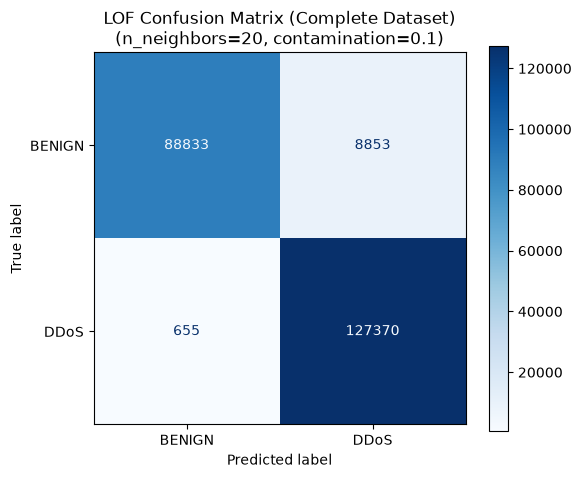

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_final, display_labels=["BENIGN", "DDoS"],
    cmap="Blues", values_format='d', ax=ax
)
plt.title(f"LOF Confusion Matrix (Complete Dataset)\n(n_neighbors={best_n}, contamination={best_c})")
plt.savefig("../figures/lof_complete_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
